##Problem Statement

Objective:
Analyze the protein supplement products dataset to understand the market trends, pricing patterns, and customer ratings for different brands and flavors. This will help identify popular products, detect pricing anomalies, and guide purchasing or business strategy.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!pip install requests beautifulsoup4 pandas lxml


In [ ]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
import requests

url = "https://www.amazon.co.uk/s?k=whey+protein+powder&crid=1VOJOQ8YKRKX&currency=INR&sprefix=whey+protein+powder%2Caps%2C506&ref=nb_sb_noss_1"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.5845.110 Safari/537.36",
    "Accept": "application/json"
}

response = requests.get(url, headers=headers)
response




<Response [503]>

In [ ]:
soup = BeautifulSoup(response.content, 'lxml')

# Each product block
products = soup.find_all('div', {'data-component-type': 's-search-result'})

print(f"Found {len(products)} products on this page")


Found 0 products on this page


In [ ]:
brands, models, sizes, flavors = [], [], [], []
prices, ratings, num_ratings = [], [], []

# Loop through each product
for product in products:
    # ---- TITLE ----
    title_tag = product.find('h2')
    title = title_tag.text.strip() if title_tag else ""

    # ---- BRAND & MODEL ----
    parts = title.split(" ", 1)
    brand = parts[0] if len(parts) > 0 else ""
    model = parts[1] if len(parts) > 1 else ""

    # ---- SIZE ----
    size_match = re.search(r'(\d+\.?\d*\s?(g|kg|ml|l))', title, re.I)
    size = size_match.group(1) if size_match else None

    # ---- FLAVOR ----
    flavor_match = re.search(r'(Chocolate|Vanilla|Strawberry|Banana|Unflavoured)', title, re.I)
    flavor = flavor_match.group(1) if flavor_match else None

    # ---- PRICE ----
    price_tag = product.find('span', {'class':'a-color-base'})
    if price_tag:
        # Extract numeric part using regex
        match = re.search(r'([\d,.]+)', price_tag.text)
        if match:
            price_text = match.group(1).replace(',', '')  # remove commas
            try:
                price = float(price_text)
            except:
                price = None
        else:
            price = None
    else:
        price = None

    # ---- RATING ----
    rating_tag = product.find('span', {'class':'a-icon-alt'})
    rating = rating_tag.text.split()[0] if rating_tag else None

    # ---- NUMBER OF RATINGS ----
    num_tag = product.find('span', {'class':'a-size-base s-underline-text'})
    num_rating = re.sub(r'[^0-9]', '', num_tag.text) if num_tag else None

    # Append to lists
    brands.append(brand)
    models.append(model)
    sizes.append(size)
    flavors.append(flavor)
    prices.append(price)
    ratings.append(float(rating) if rating else None)
    num_ratings.append(int(num_rating) if num_rating else None)

# ---- Create DataFrame ----
df = pd.DataFrame({
    "Brand": brands,
    "Model Name": models,
    "Size": sizes,
    "Flavor": flavors,
    "Price": prices,
    "Rating": ratings,
    "Number of Ratings": num_ratings
})

df.head()

,Brand,Model Name,Size,Flavor,Price,Rating,Number of Ratings


# for  all pages

In [ ]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import time

# Base URL
base_url = "https://www.amazon.co.uk/s?k=whey+protein+powder&crid=1VOJOQ8YKRKX&currency=INR&sprefix=whey+protein+powder%2Caps%2C506&page="

# Headers
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.5845.110 Safari/537.36",
    "Accept-Language": "en-GB,en;q=0.9"
}

# Lists to store data
brands, models, sizes, flavors = [], [], [], []
prices, ratings, num_ratings = [], [], []

# ---- Manually set total pages ----
num_pages = 7

for page in range(1, num_pages + 1):
    print(f"Scraping page {page}...")
    url = base_url + str(page)

    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, 'lxml')

    products = soup.find_all('div', {'data-component-type': 's-search-result'})

    for product in products:
        # ---- TITLE ----
        title_tag = product.find('h2')
        title = title_tag.text.strip() if title_tag else ""

        # ---- BRAND & MODEL ----
        parts = title.split(" ", 1)
        brand = parts[0] if len(parts) > 0 else ""
        model = parts[1] if len(parts) > 1 else ""

        # ---- SIZE ----
        size_match = re.search(r'(\d+\.?\d*\s?(g|kg|ml|l))', title, re.I)
        size = size_match.group(1) if size_match else None

        # ---- FLAVOR ----
        flavor_match = re.search(r'(Chocolate|Vanilla|Strawberry|Banana|Unflavoured)', title, re.I)
        flavor = flavor_match.group(1) if flavor_match else None

        # ---- PRICE ----
        price_tag = product.find('span', {'class':'a-color-base'})
        if price_tag:
            match = re.search(r'([\d,.]+)', price_tag.text)
            if match:
                price_text = match.group(1).replace(',', '')
                try:
                    price = float(price_text)
                except:
                    price = None
            else:
                price = None
        else:
            price = None

        # ---- RATING ----
        rating_tag = product.find('span', {'class':'a-icon-alt'})
        rating = rating_tag.text.split()[0] if rating_tag else None

        # ---- NUMBER OF RATINGS ----
        num_tag = product.find('span', {'class':'a-size-base s-underline-text'})
        num_rating = re.sub(r'[^0-9]', '', num_tag.text) if num_tag else None

        # Append to lists
        brands.append(brand)
        models.append(model)
        sizes.append(size)
        flavors.append(flavor)
        prices.append(price)
        ratings.append(float(rating) if rating else None)
        num_ratings.append(int(num_rating) if num_rating else None)

    # polite delay to avoid getting blocked
    time.sleep(2)

# ---- Create DataFrame ----
df = pd.DataFrame({
    "Brand": brands,
    "Model Name": models,
    "Size": sizes,
    "Flavor": flavors,
    "Price": prices,
    "Rating": ratings,
    "Number of Ratings": num_ratings
})

print(f"Total products scraped: {len(df)}")
df.head()


Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Total products scraped: 48


,Brand,Model Name,Size,Flavor,Price,Rating,Number of Ratings
0,MyProtein,Impact Whey Isolate - Chocolate Smooth - 500g ...,500g,Chocolate,5.0,5.0,None
1,Weider,Whey Protein (300g) Vanilla Flavour. Whey Prot...,300g,Vanilla,4.7,4.7,None
2,KMC,PRO Mix: Chocolate Mint Flavour Whey Protein R...,40g,Chocolate,3.5,3.5,None
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,900g,Banana,4.4,4.4,None
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,55g,None,4.4,4.4,None


In [ ]:
df

,Brand,Model Name,Size,Flavor,Price,Rating,Number of Ratings
0,MyProtein,Impact Whey Isolate - Chocolate Smooth - 500g ...,500g,Chocolate,5.00,5.0,None
1,Weider,Whey Protein (300g) Vanilla Flavour. Whey Prot...,300g,Vanilla,4.70,4.7,None
2,KMC,PRO Mix: Chocolate Mint Flavour Whey Protein R...,40g,Chocolate,3.50,3.5,None
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,900g,Banana,4.40,4.4,None
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,55g,None,4.40,4.4,None
5,Weider,Isolate Whey 100 CFM (908g) Vanilla Cream Flav...,908g,Vanilla,4.50,4.5,None
6,MUTANT,"Mass | Muscle Mass Gainer | 1100 Calories, 56g...",56g,Chocolate,4.50,4.5,None
7,Protein,"Works - Whey Protein 360, Premium Whey Protein...",2.4 kg,None,4.70,4.7,None
8,Naturya,"Organic Hemp Protein Powder, 300g",300g,None,4.40,4.4,None
9,Olimp,"Labs Whey Protein Complex,, , Vanilla, 2270 gram",2270 g,Vanilla,4.60,4.6,None


# Data Cleaning

In [ ]:
import numpy as np

# Fill missing categorical columns with 'Unknown'
df['Brand'].fillna('Unknown', inplace=True)
df['Model Name'].fillna('Unknown', inplace=True)
df['Size'].fillna('Unknown', inplace=True)
df['Flavor'].fillna('Unknown', inplace=True)

# Convert numeric columns to proper types, keep NaN for invalid/missing values
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Number of Ratings'] = pd.to_numeric(df['Number of Ratings'], errors='coerce')

# View cleaned dataset
df.head()


/tmp/ipython-input-778055674.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Brand'].fillna('Unknown', inplace=True)
/tmp/ipython-input-778055674.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

,Brand,Model Name,Size,Flavor,Price,Rating,Number of Ratings
0,MyProtein,Impact Whey Isolate - Chocolate Smooth - 500g ...,500g,Chocolate,5.0,5.0,NaN
1,Weider,Whey Protein (300g) Vanilla Flavour. Whey Prot...,300g,Vanilla,4.7,4.7,NaN
2,KMC,PRO Mix: Chocolate Mint Flavour Whey Protein R...,40g,Chocolate,3.5,3.5,NaN
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,900g,Banana,4.4,4.4,NaN
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,55g,Unknown,4.4,4.4,NaN


In [ ]:
df

,Brand,Model Name,Size,Flavor,Price,Rating,Number of Ratings
0,MyProtein,Impact Whey Isolate - Chocolate Smooth - 500g ...,500g,Chocolate,5.00,5.0,NaN
1,Weider,Whey Protein (300g) Vanilla Flavour. Whey Prot...,300g,Vanilla,4.70,4.7,NaN
2,KMC,PRO Mix: Chocolate Mint Flavour Whey Protein R...,40g,Chocolate,3.50,3.5,NaN
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,900g,Banana,4.40,4.4,NaN
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,55g,Unknown,4.40,4.4,NaN
5,Weider,Isolate Whey 100 CFM (908g) Vanilla Cream Flav...,908g,Vanilla,4.50,4.5,NaN
6,MUTANT,"Mass | Muscle Mass Gainer | 1100 Calories, 56g...",56g,Chocolate,4.50,4.5,NaN
7,Protein,"Works - Whey Protein 360, Premium Whey Protein...",2.4 kg,Unknown,4.70,4.7,NaN
8,Naturya,"Organic Hemp Protein Powder, 300g",300g,Unknown,4.40,4.4,NaN
9,Olimp,"Labs Whey Protein Complex,, , Vanilla, 2270 gram",2270 g,Vanilla,4.60,4.6,NaN


checking miss values

In [ ]:
df.isnull().sum()

NameError: name 'df' is not defined

In [ ]:
df['Price'] = df['Price'].replace('[₹,]', '', regex=True).astype(float)


In [ ]:
df = df.apply(lambda x: x.str.strip().str.title() if x.dtype == "object" else x)


In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
print(df.dtypes)

Brand                 object
Model Name            object
Size                  object
Flavor                object
Price                float64
Rating               float64
Number of Ratings    float64
dtype: object


In [ ]:
#  Import needed libraries
import pandas as pd
import numpy as np

# Assuming df is your cleaned DataFrame

#  Convert Size to numeric (extract grams or kg and convert all to grams)
def convert_size_to_grams(size):
    size = str(size).lower().replace(' ', '')
    if 'kg' in size:
        return float(size.replace('kg', '').strip()) * 1000
    elif 'g' in size:
        return float(size.replace('g', '').strip())
    else:
        return np.nan

df['Size_grams'] = df['Size'].apply(convert_size_to_grams)

#  Clean price (already float, just ensure correct type)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

#  Calculate price per 100g (helps in comparisons)
df['Price_per_100g'] = (df['Price'] / df['Size_grams']) * 100

#  Clean brand names (remove extra spaces & make consistent case)
df['Brand'] = df['Brand'].str.strip().str.title()

#  Clean flavor text
df['Flavor'] = df['Flavor'].str.strip().str.title()

#  Fill NaN ratings with median and number of ratings with 0 (optional)
df['Rating'].fillna(df['Rating'].median(), inplace=True)
df['Number of Ratings'].fillna(0, inplace=True)

#  Reorder columns for neatness
df = df[['Brand', 'Model Name', 'Flavor', 'Size', 'Size_grams',
         'Price', 'Price_per_100g', 'Rating', 'Number of Ratings']]

#  Quick summary check
print(df.head())
print("\nDescriptive statistics:\n", df.describe())


       Brand                                         Model Name     Flavor  \
0  Myprotein  Impact Whey Isolate - Chocolate Smooth - 500G ...  Chocolate   
1     Weider  Whey Protein (300G) Vanilla Flavour. Whey Prot...    Vanilla   
2        Kmc  Pro Mix: Chocolate Mint Flavour Whey Protein R...  Chocolate   
3     Reflex  Nutrition Instant Whey™ Pro - 80% Whey Protein...     Banana   
4     Reflex  Nutrition One Stop® Xtreme - Serious Mass Gain...    Unknown   

   Size  Size_grams  Price  Price_per_100g  Rating  Number of Ratings  
0  500G       500.0    5.0        1.000000     5.0                0.0  
1  300G       300.0    4.7        1.566667     4.7                0.0  
2   40G        40.0    3.5        8.750000     3.5                0.0  
3  900G       900.0    4.4        0.488889     4.4                0.0  
4   55G        55.0    4.4        8.000000     4.4                0.0  

Descriptive statistics:
         Size_grams      Price  Price_per_100g     Rating  Number of Ratin

/tmp/ipython-input-656417741.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].median(), inplace=True)
/tmp/ipython-input-656417741.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
df.isnull().sum()

,0
Brand,0
Model Name,0
Flavor,0
Size,0
Size_grams,5
Price,5
Price_per_100g,10
Rating,0
Number of Ratings,0


In [ ]:
df

,Brand,Model Name,Flavor,Size,Size_grams,Price,Price_per_100g,Rating,Number of Ratings
0,Myprotein,Impact Whey Isolate - Chocolate Smooth - 500G ...,Chocolate,500G,500.0,5.00,1.000000,5.0,0.0
1,Weider,Whey Protein (300G) Vanilla Flavour. Whey Prot...,Vanilla,300G,300.0,4.70,1.566667,4.7,0.0
2,Kmc,Pro Mix: Chocolate Mint Flavour Whey Protein R...,Chocolate,40G,40.0,3.50,8.750000,3.5,0.0
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,Banana,900G,900.0,4.40,0.488889,4.4,0.0
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,Unknown,55G,55.0,4.40,8.000000,4.4,0.0
5,Weider,Isolate Whey 100 Cfm (908G) Vanilla Cream Flav...,Vanilla,908G,908.0,4.50,0.495595,4.5,0.0
6,Mutant,"Mass | Muscle Mass Gainer | 1100 Calories, 56G...",Chocolate,56G,56.0,4.50,8.035714,4.5,0.0
7,Protein,"Works - Whey Protein 360, Premium Whey Protein...",Unknown,2.4 Kg,2400.0,4.70,0.195833,4.7,0.0
8,Naturya,"Organic Hemp Protein Powder, 300G",Unknown,300G,300.0,4.40,1.466667,4.4,0.0
9,Olimp,"Labs Whey Protein Complex,, , Vanilla, 2270 Gram",Vanilla,2270 G,2270.0,4.60,0.202643,4.6,0.0


In [ ]:
 # Step 1: Replace 'Unknown' in Size or Flavor with NaN for uniformity
df['Size'] = df['Size'].replace('Unknown', np.nan)
df['Flavor'] = df['Flavor'].replace('Unknown', np.nan)

# Step 2: Fill missing Flavor with 'Unknown'
df['Flavor'] = df['Flavor'].fillna('Unknown')

# Step 3: Fill missing Size_grams using a mapping from Size (if possible)
# Convert Size to grams if Size is a string like "2.26 Kg" or "36G"
def size_to_grams(size):
    if pd.isna(size):
        return np.nan
    size = str(size).strip()
    if 'kg' in size.lower():
        return float(size.lower().replace('kg','').strip()) * 1000
    elif 'g' in size.lower():
        return float(size.lower().replace('g','').strip())
    else:
        return np.nan

df['Size_grams'] = df['Size_grams'].fillna(df['Size'].apply(size_to_grams))

# Step 4: Fill missing Price with median price
df['Price'] = df['Price'].fillna(df['Price'].median())

# Step 5: Recalculate Price_per_100g if missing
df['Price_per_100g'] = df['Price_per_100g'].fillna((df['Price'] / df['Size_grams']) * 100)

# Step 6: Fill missing Rating with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Step 7: Fill missing Number of Ratings with 0
df['Number of Ratings'] = df['Number of Ratings'].fillna(0)

# Check missing values after cleaning
df.isnull().sum()

,0
Brand,0
Model Name,0
Flavor,0
Size,5
Size_grams,5
Price,0
Price_per_100g,5
Rating,0
Number of Ratings,0


In [ ]:
df

,Brand,Model Name,Flavor,Size,Size_grams,Price,Price_per_100g,Rating,Number of Ratings
0,Myprotein,Impact Whey Isolate - Chocolate Smooth - 500G ...,Chocolate,500G,500.0,5.00,1.000000,5.0,0.0
1,Weider,Whey Protein (300G) Vanilla Flavour. Whey Prot...,Vanilla,300G,300.0,4.70,1.566667,4.7,0.0
2,Kmc,Pro Mix: Chocolate Mint Flavour Whey Protein R...,Chocolate,40G,40.0,3.50,8.750000,3.5,0.0
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,Banana,900G,900.0,4.40,0.488889,4.4,0.0
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,Unknown,55G,55.0,4.40,8.000000,4.4,0.0
5,Weider,Isolate Whey 100 Cfm (908G) Vanilla Cream Flav...,Vanilla,908G,908.0,4.50,0.495595,4.5,0.0
6,Mutant,"Mass | Muscle Mass Gainer | 1100 Calories, 56G...",Chocolate,56G,56.0,4.50,8.035714,4.5,0.0
7,Protein,"Works - Whey Protein 360, Premium Whey Protein...",Unknown,2.4 Kg,2400.0,4.70,0.195833,4.7,0.0
8,Naturya,"Organic Hemp Protein Powder, 300G",Unknown,300G,300.0,4.40,1.466667,4.4,0.0
9,Olimp,"Labs Whey Protein Complex,, , Vanilla, 2270 Gram",Vanilla,2270 G,2270.0,4.60,0.202643,4.6,0.0


In [ ]:
# Drop rows where Size_grams is still missing (can't calculate price per 100g without size)
df = df.dropna(subset=['Size_grams'])

# Recalculate Price_per_100g just to be safe
df['Price_per_100g'] = (df['Price'] / df['Size_grams']) * 100

# Check missing values again
(df.isnull().sum())


/tmp/ipython-input-256990987.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price_per_100g'] = (df['Price'] / df['Size_grams']) * 100


,0
Brand,0
Model Name,0
Flavor,0
Size,0
Size_grams,0
Price,0
Price_per_100g,0
Rating,0
Number of Ratings,0


In [ ]:
df

,Brand,Model Name,Flavor,Size,Size_grams,Price,Price_per_100g,Rating,Number of Ratings
0,Myprotein,Impact Whey Isolate - Chocolate Smooth - 500G ...,Chocolate,500G,500.0,5.00,1.000000,5.0,0.0
1,Weider,Whey Protein (300G) Vanilla Flavour. Whey Prot...,Vanilla,300G,300.0,4.70,1.566667,4.7,0.0
2,Kmc,Pro Mix: Chocolate Mint Flavour Whey Protein R...,Chocolate,40G,40.0,3.50,8.750000,3.5,0.0
3,Reflex,Nutrition Instant Whey™ Pro - 80% Whey Protein...,Banana,900G,900.0,4.40,0.488889,4.4,0.0
4,Reflex,Nutrition One Stop® Xtreme - Serious Mass Gain...,Unknown,55G,55.0,4.40,8.000000,4.4,0.0
5,Weider,Isolate Whey 100 Cfm (908G) Vanilla Cream Flav...,Vanilla,908G,908.0,4.50,0.495595,4.5,0.0
6,Mutant,"Mass | Muscle Mass Gainer | 1100 Calories, 56G...",Chocolate,56G,56.0,4.50,8.035714,4.5,0.0
7,Protein,"Works - Whey Protein 360, Premium Whey Protein...",Unknown,2.4 Kg,2400.0,4.70,0.195833,4.7,0.0
8,Naturya,"Organic Hemp Protein Powder, 300G",Unknown,300G,300.0,4.40,1.466667,4.4,0.0
9,Olimp,"Labs Whey Protein Complex,, , Vanilla, 2270 Gram",Vanilla,2270 G,2270.0,4.60,0.202643,4.6,0.0


#Checking Outlier

In [ ]:
import pandas as pd

# Numeric columns to check for outliers
numeric_cols = ['Price', 'Price_per_100g', 'Size_grams', 'Rating']

outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Identify outliers
    outliers = df[(df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))]
    outliers_dict[col] = outliers

    print(f"--- Outliers in {col} ---")
    if not outliers.empty:
        print(outliers[['Brand','Model Name','Flavor','Size_grams','Price','Price_per_100g','Rating']])
    else:
        print("No outliers found")
    print("\n")


--- Outliers in Price ---
         Brand                                         Model Name     Flavor  \
18     Naughty  Boy Advanced Whey Protein Powder, Optimum Tast...  Chocolate   
34  Biotechusa                   100% Pure Whey, Chocolate - 454G  Chocolate   
38      Scitec  Nutrition Radical Whey - Whey Protein Concentr...  Chocolate   
44     Naughty  Boy Advanced Whey Protein Powder, Optimum Tast...    Unknown   
46   Myprotein  Pro X Hyrox - The Recovery Protein Orange & Ma...    Unknown   

    Size_grams  Price  Price_per_100g  Rating  
18       900.0   1.00        0.111111     1.0  
34       454.0  18.44        4.061674     4.2  
38      2000.0  38.78        1.939000     4.2  
44       900.0   2.00        0.222222     2.0  
46       680.0  32.00        4.705882     4.2  


--- Outliers in Price_per_100g ---
         Brand                                         Model Name     Flavor  \
10   Myprotein  Impact Diet Whey Protein Powder – Chocolate Mi...  Chocolate   
16     O

/tmp/ipython-input-1923941485.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


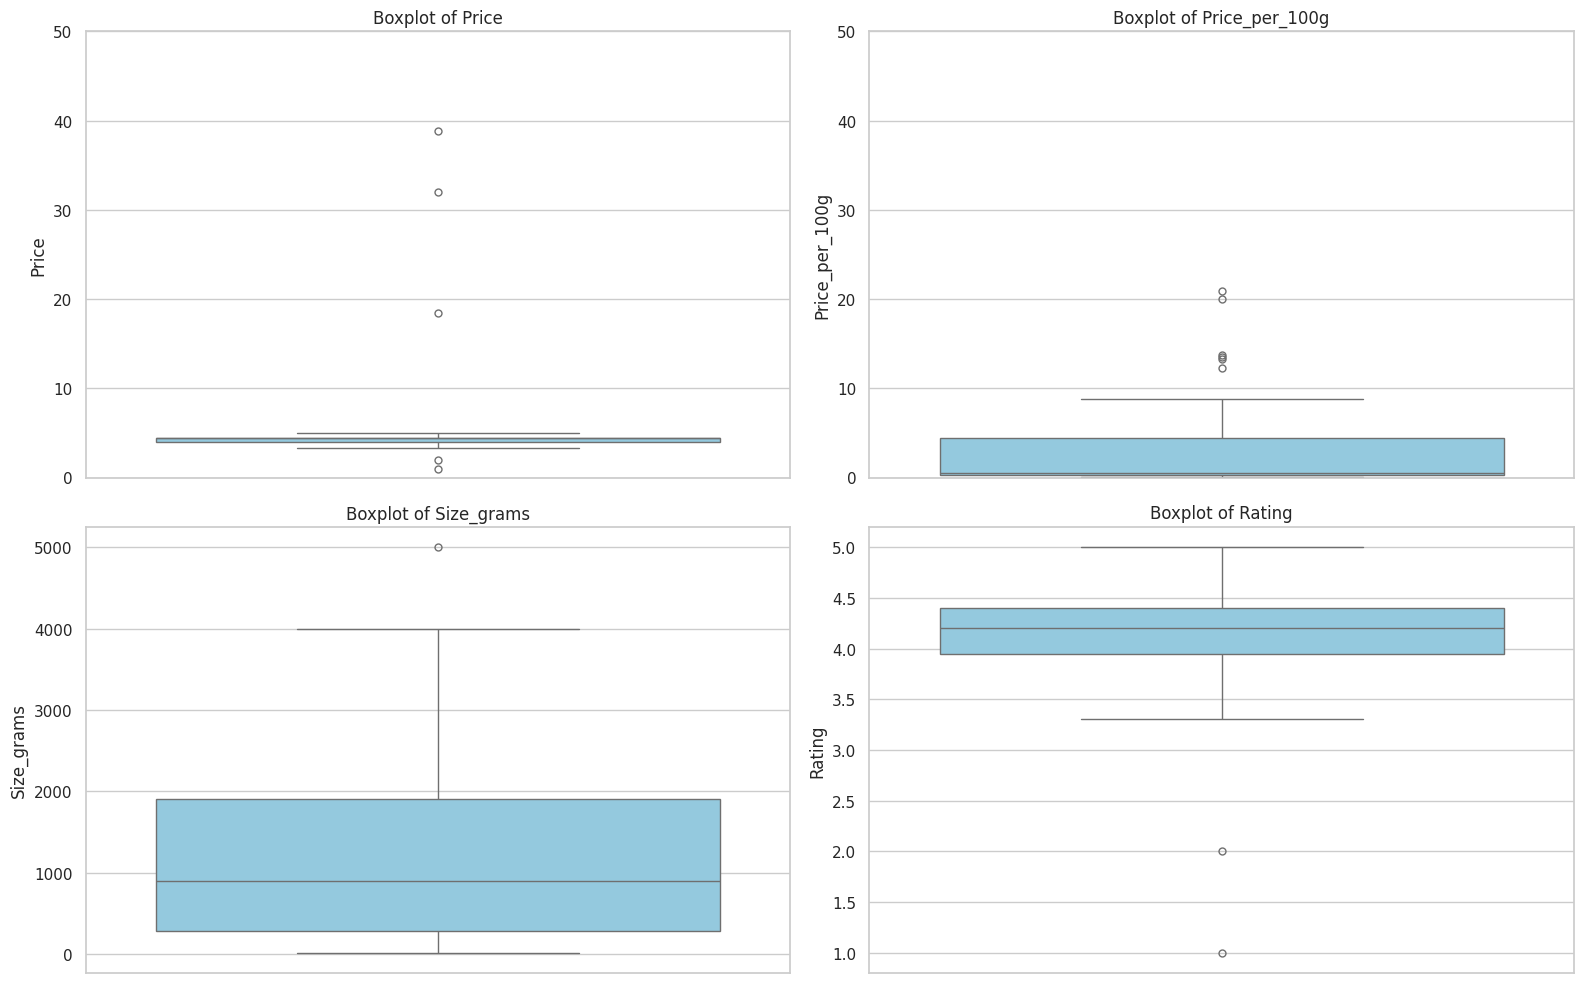

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric columns
numeric_cols = ['Price', 'Price_per_100g', 'Size_grams', 'Rating']

# Ensure numeric types
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create boxplots
plt.figure(figsize=(16,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue', fliersize=5)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    # Optional: zoom in for better visualization if needed
    if col in ['Price_per_100g', 'Price']:
        plt.ylim(0, 50)  # focus on main range

plt.tight_layout()
plt.show()


In [ ]:
numeric_cols = ['Price', 'Price_per_100g', 'Size_grams', 'Rating']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df_clean = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f"Original data: {df.shape[0]} rows")
    print(f"After removing outliers: {df_clean.shape[0]} rows")

Original data: 43 rows
After removing outliers: 38 rows
Original data: 43 rows
After removing outliers: 37 rows
Original data: 43 rows
After removing outliers: 42 rows
Original data: 43 rows
After removing outliers: 41 rows


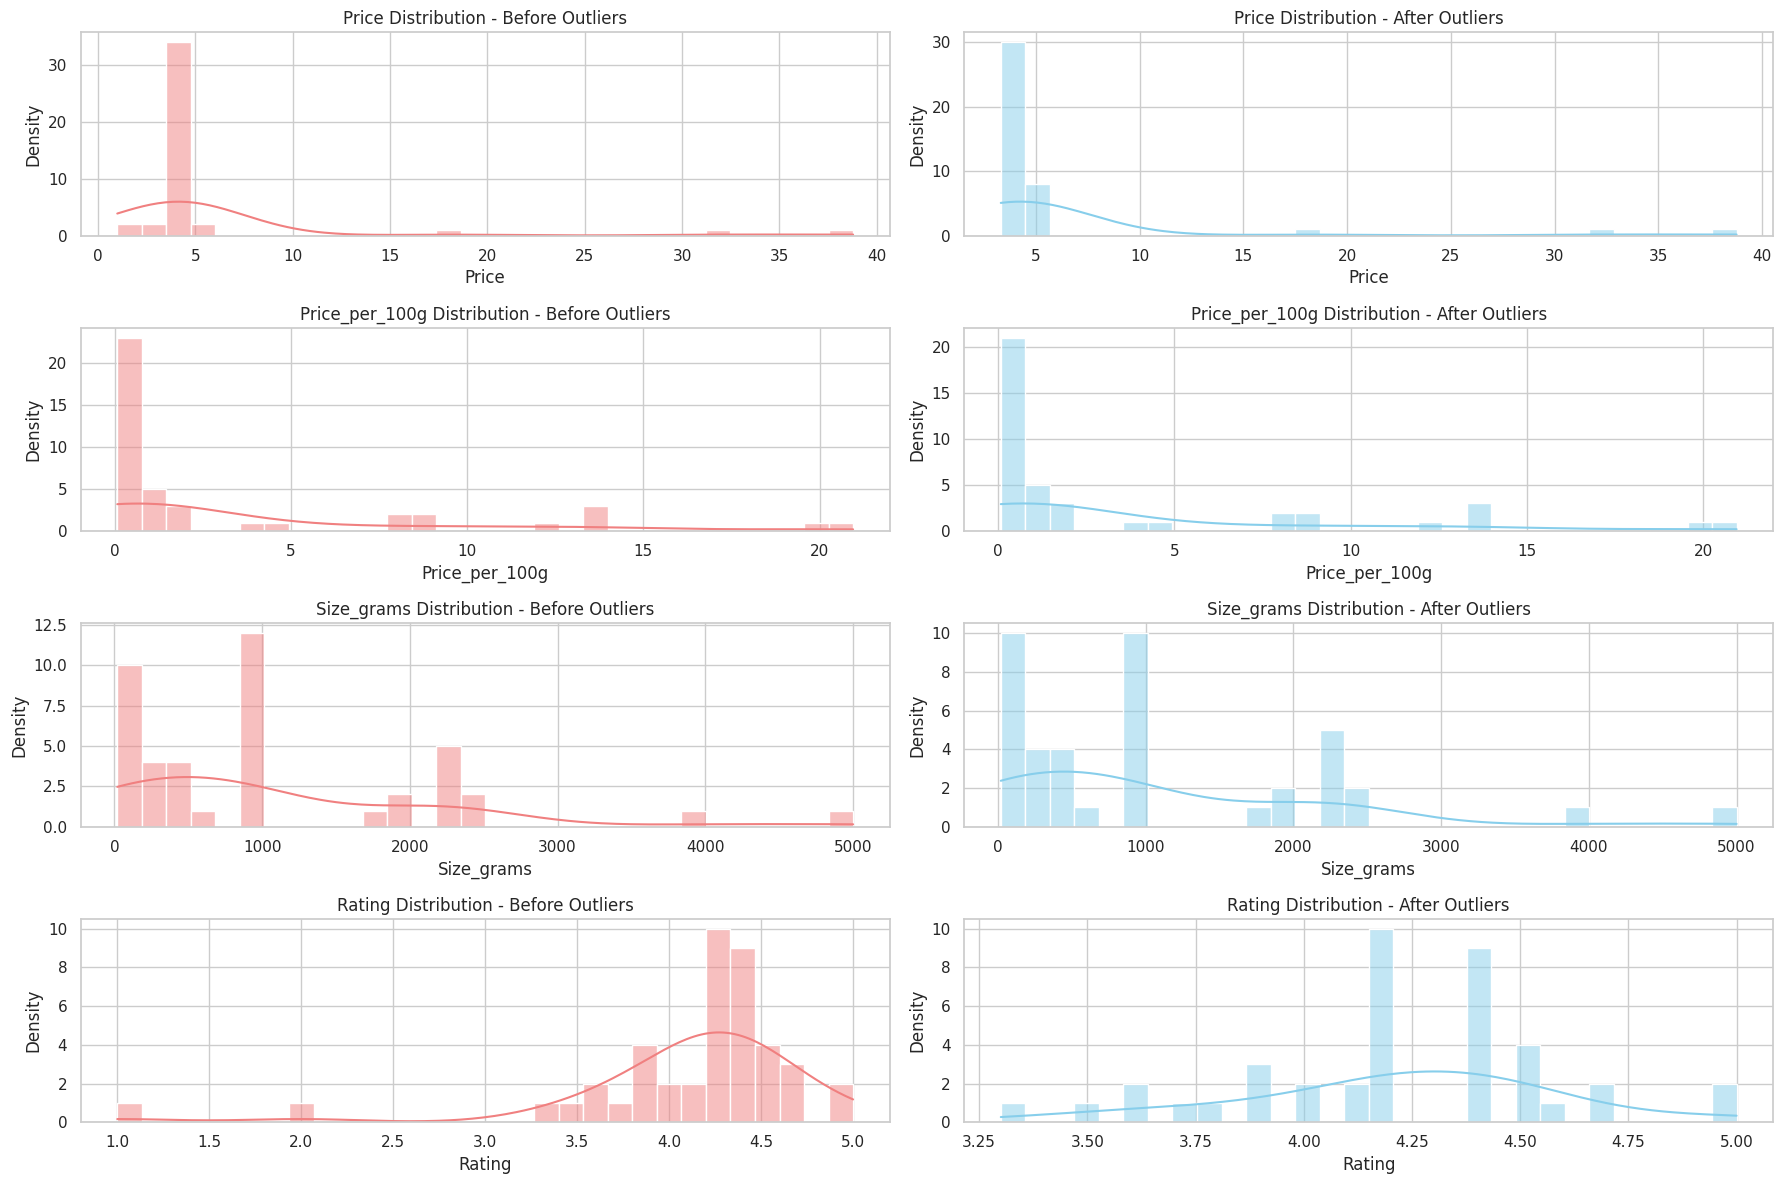

In [ ]:
plt.figure(figsize=(18,12))

for i, col in enumerate(numeric_cols, 1):
    # Before outliers
    plt.subplot(4, 2, 2*i-1)
    sns.histplot(df[col], color='lightcoral', kde=True, bins=30)
    plt.title(f'{col} Distribution - Before Outliers')
    plt.xlabel(col)
    plt.ylabel('Density')

    # After outliers
    plt.subplot(4, 2, 2*i)
    sns.histplot(df_clean[col], color='skyblue', kde=True, bins=30)
    plt.title(f'{col} Distribution - After Outliers')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

#EDA

Identify Variable Types

###Categorical variables:

Brand, Flavor

###Numeric variables:

Price, Price_per_100g, Size_grams, Rating, Number of Ratings



##Numeric Variables (Price, Price_per_100g, Size_grams, Rating, Number of Ratings)

###a) Summary Statistics

In [ ]:
numeric_cols = ['Price', 'Price_per_100g', 'Size_grams', 'Rating', 'Number of Ratings']
df_clean[numeric_cols].describe()


,Price,Price_per_100g,Size_grams,Rating,Number of Ratings
count,41.000000,41.000000,41.000000,41.000000,41.0
mean,6.105366,3.736338,1076.414634,4.219512,0.0
std,7.120598,5.707681,1138.405837,0.368931,0.0
min,3.300000,0.078000,20.000000,3.300000,0.0
25%,4.000000,0.248756,280.000000,4.000000,0.0
50%,4.400000,0.495595,900.000000,4.200000,0.0
75%,4.500000,4.705882,2000.000000,4.400000,0.0
max,38.780000,20.952381,5000.000000,5.000000,0.0


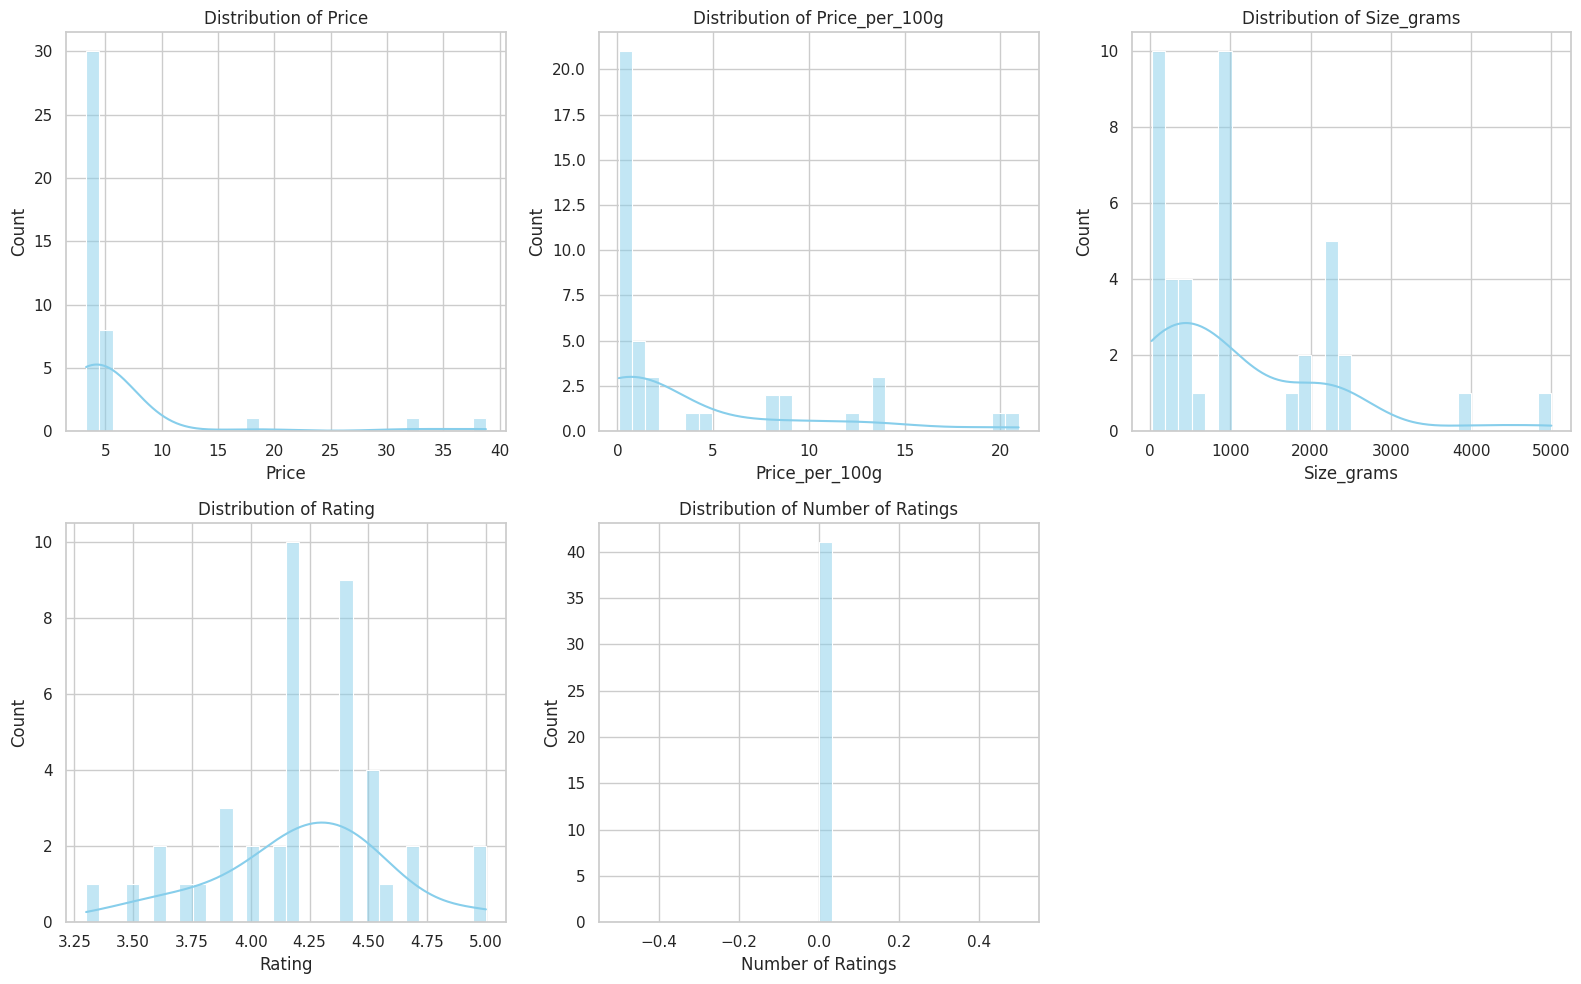

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_clean[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

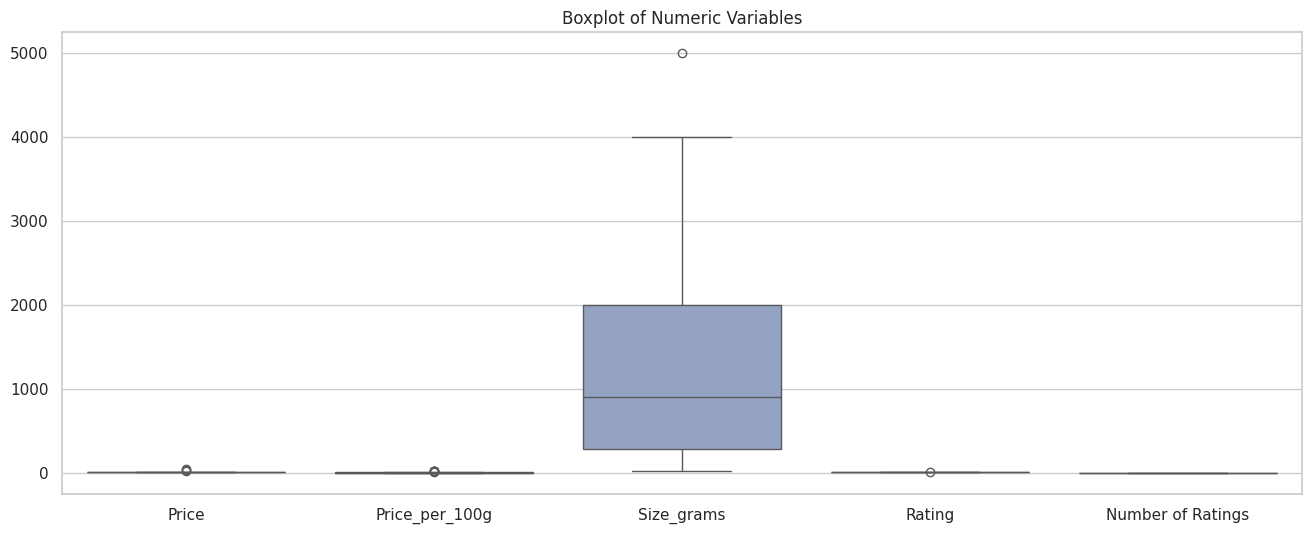

In [ ]:
plt.figure(figsize=(16,6))
sns.boxplot(data=df_clean[numeric_cols], palette='Set2')
plt.title('Boxplot of Numeric Variables')
plt.show()


##Categorical Variables (Brand, Flavor)

## a) Frequency Counts

/tmp/ipython-input-1357873621.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='Set2')


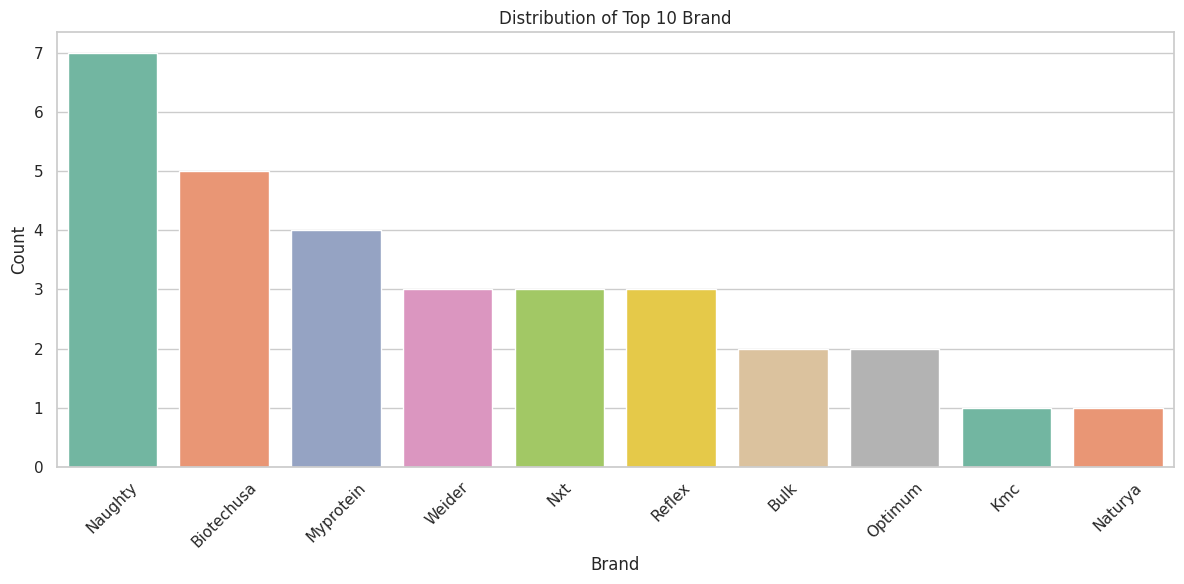

/tmp/ipython-input-1357873621.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='Set2')


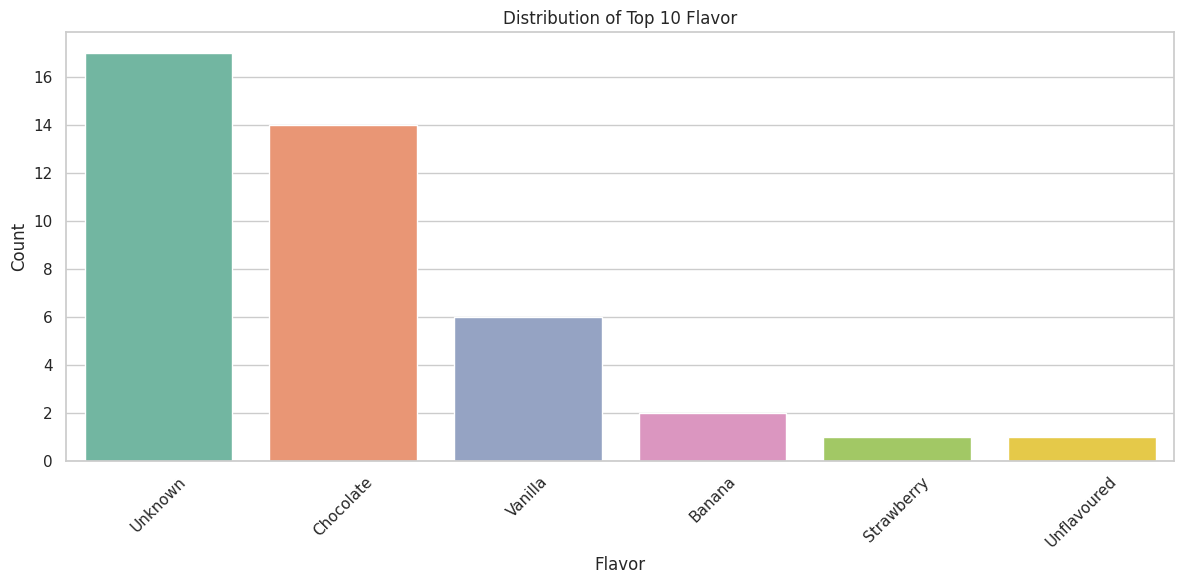

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Brand', 'Flavor']

for col in categorical_cols:
    plt.figure(figsize=(12,6))
    top_values = df_clean[col].value_counts().nlargest(10)  # Top 10 for readability
    sns.barplot(x=top_values.index, y=top_values.values, palette='Set2')
    plt.title(f'Distribution of Top 10 {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3963213224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean[df_clean['Brand'].isin(top_brands)],
/tmp/ipython-input-3963213224.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Flavor', order=df_clean['Flavor'].value_counts().index, palette='Set2')


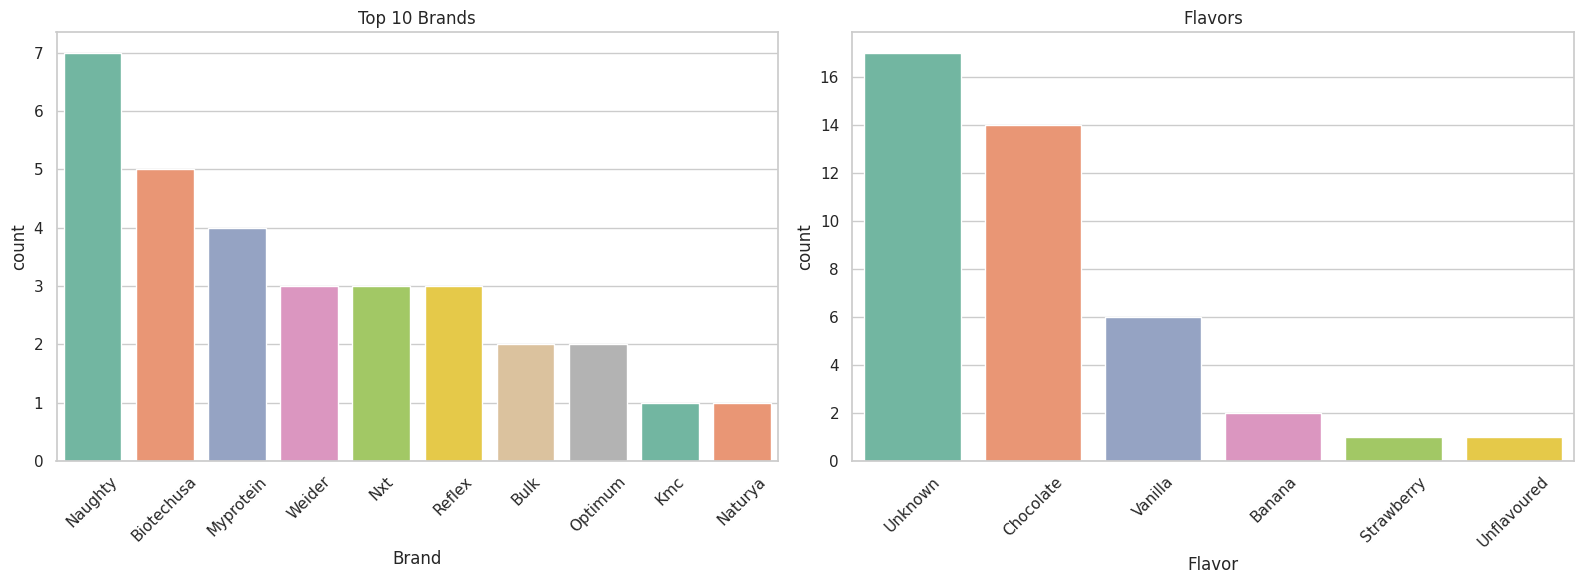

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Brand', 'Flavor']

plt.figure(figsize=(16,6))

# Top 10 Brands
plt.subplot(1,2,1)
top_brands = df_clean['Brand'].value_counts().nlargest(10).index
sns.countplot(data=df_clean[df_clean['Brand'].isin(top_brands)],
              x='Brand', order=top_brands, palette='Set2')
plt.xticks(rotation=45)
plt.title('Top 10 Brands')

# All Flavors (usually fewer, so it's okay)
plt.subplot(1,2,2)
sns.countplot(data=df_clean, x='Flavor', order=df_clean['Flavor'].value_counts().index, palette='Set2')
plt.xticks(rotation=45)
plt.title('Flavors')

plt.tight_layout()
plt.show()


## Numeric vs Numeric
a) Price vs Rating

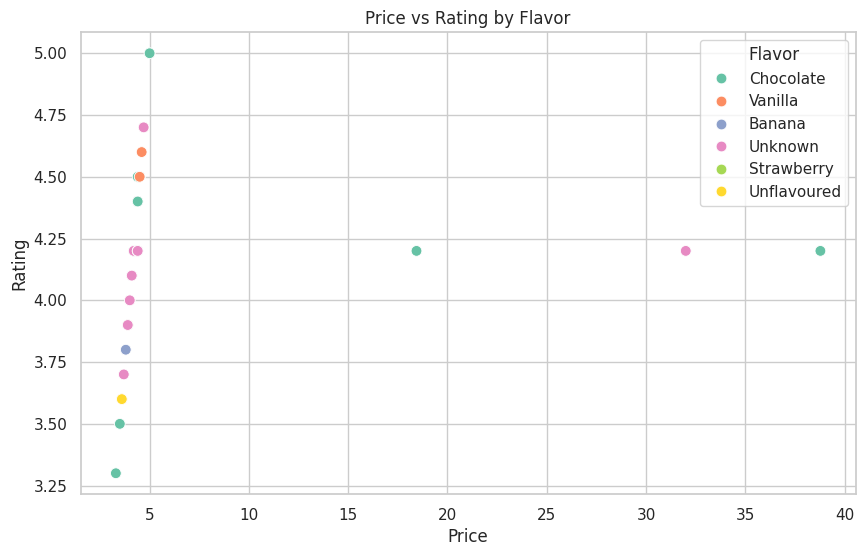

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='Price', y='Rating', hue='Flavor', palette='Set2', s=60)
plt.title('Price vs Rating by Flavor')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()


b) Correlation Heatmap (all numeric)

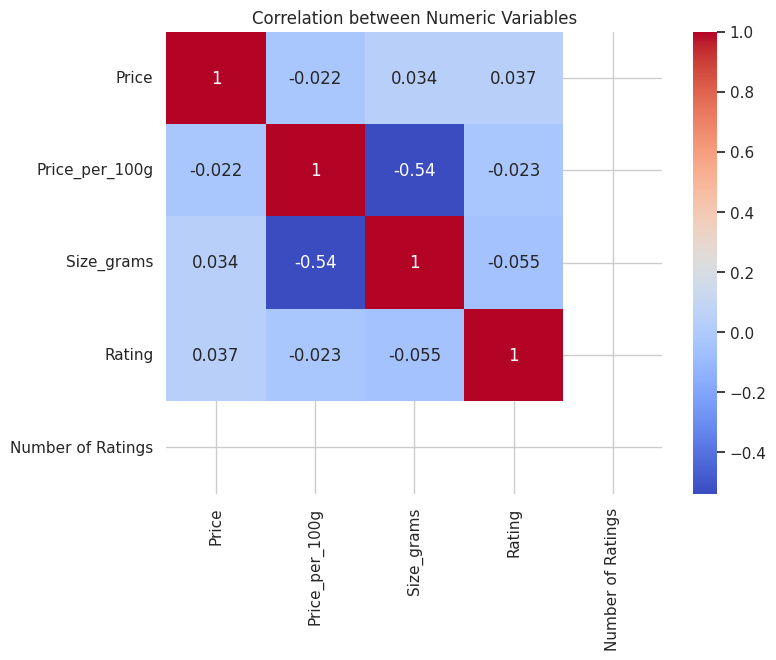

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[['Price','Price_per_100g','Size_grams','Rating','Number of Ratings']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation between Numeric Variables')
plt.show()


##Categorical vs Numeric

a) Brand vs Price

/tmp/ipython-input-764922364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean[df_clean['Brand'].isin(top_brands)], x='Brand', y='Price', palette='Set3')


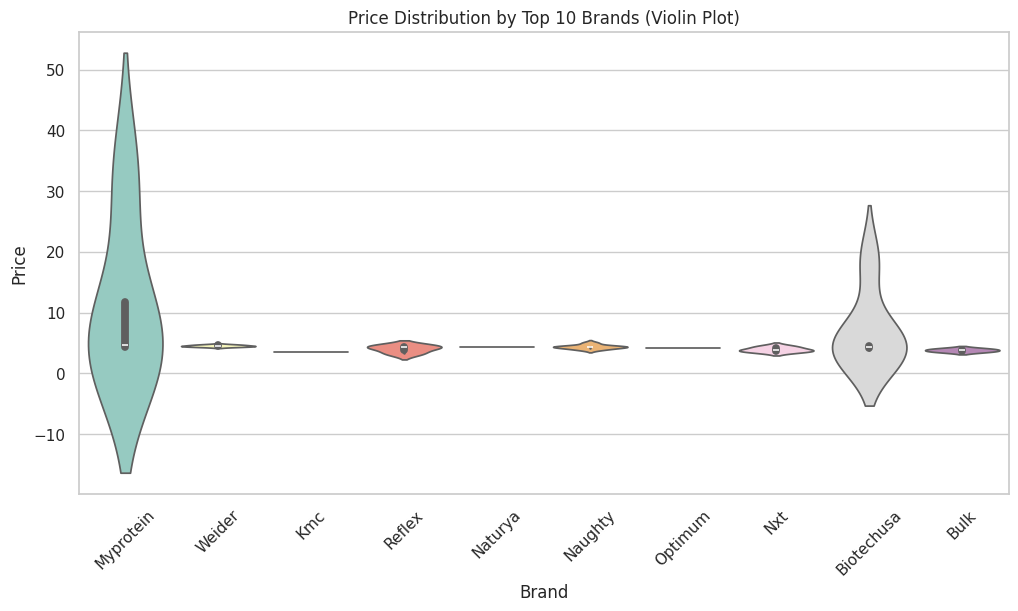

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df_clean[df_clean['Brand'].isin(top_brands)], x='Brand', y='Price', palette='Set3')
plt.xticks(rotation=45)
plt.title('Price Distribution by Top 10 Brands (Violin Plot)')
plt.show()


/tmp/ipython-input-3116194661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Flavor', y='Price', palette='Set2')


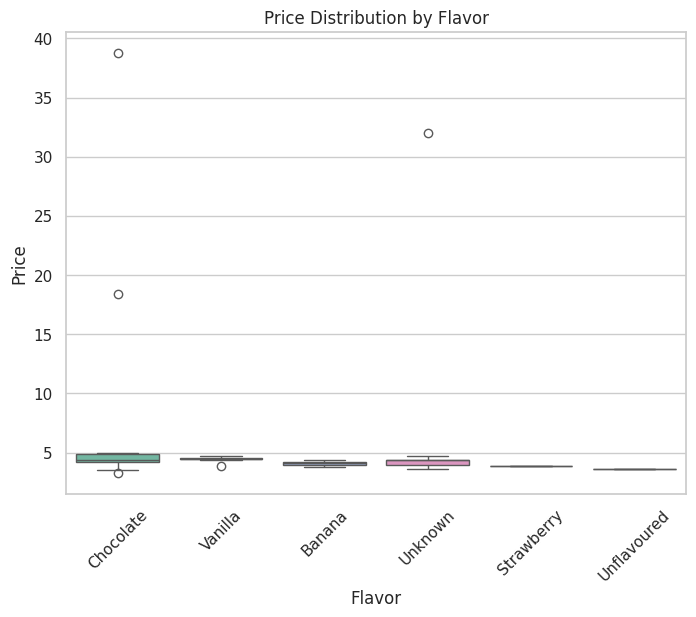

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, x='Flavor', y='Price', palette='Set2')
plt.xticks(rotation=45)
plt.title('Price Distribution by Flavor')
plt.show()


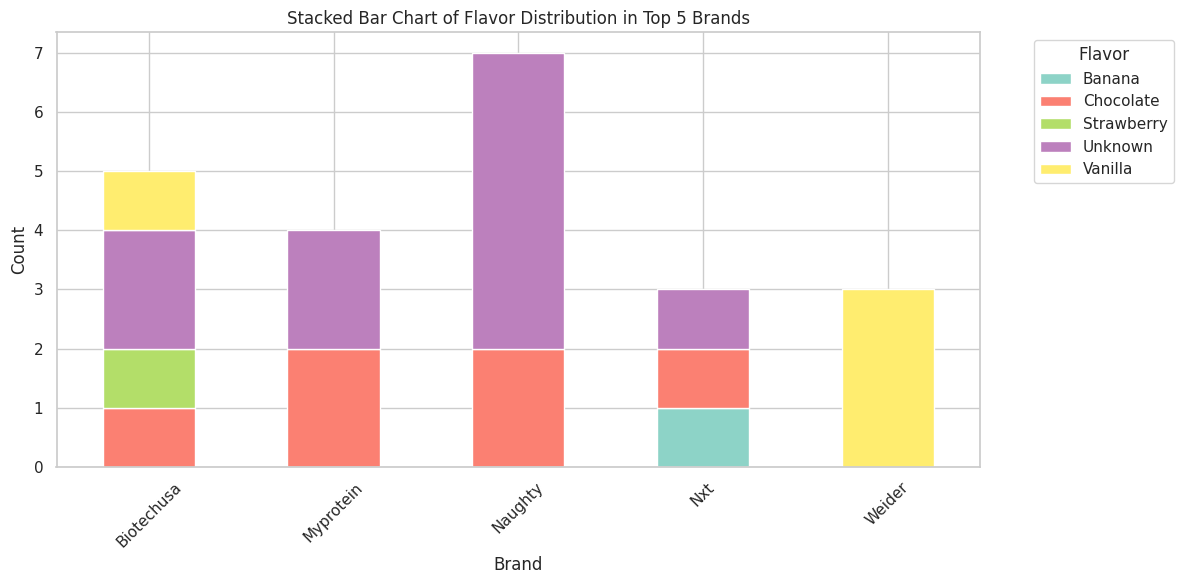

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Example: Top 5 brands only to keep chart readable
top_brands = df_clean['Brand'].value_counts().nlargest(5).index
df_top = df_clean[df_clean['Brand'].isin(top_brands)]

# Create a cross-tab of Brand vs Flavor
brand_flavor_ct = pd.crosstab(df_top['Brand'], df_top['Flavor'])

# Plot stacked bar chart
brand_flavor_ct.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set3')
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Flavor Distribution in Top 5 Brands')
plt.xticks(rotation=45)
plt.legend(title='Flavor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
pd.crosstab(df_clean['Brand'], df_clean['Flavor']).head(10)


Flavor,Banana,Chocolate,Strawberry,Unflavoured,Unknown,Vanilla
Brand,,,,,,
Applied,0,1,0,0,0,0
Biotechusa,0,1,1,0,2,1
Bulk,0,0,0,1,1,0
Gold,0,1,0,0,0,0
Kmc,0,1,0,0,0,0
"Maxinutrition,",0,0,0,0,1,0
Mutant,0,1,0,0,0,0
Myprotein,0,2,0,0,2,0
Naturya,0,0,0,0,1,0


Multivariate Analysis:

Numeric vs Numeric vs Categorical:



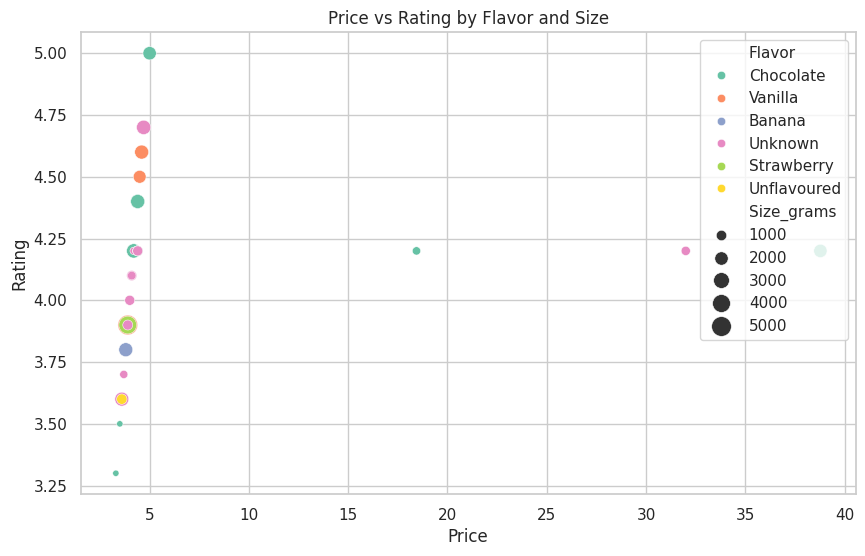

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='Price', y='Rating', hue='Flavor', size='Size_grams', palette='Set2', sizes=(20,200))
plt.title('Price vs Rating by Flavor and Size')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()


b) Pairplot (all numeric variables)

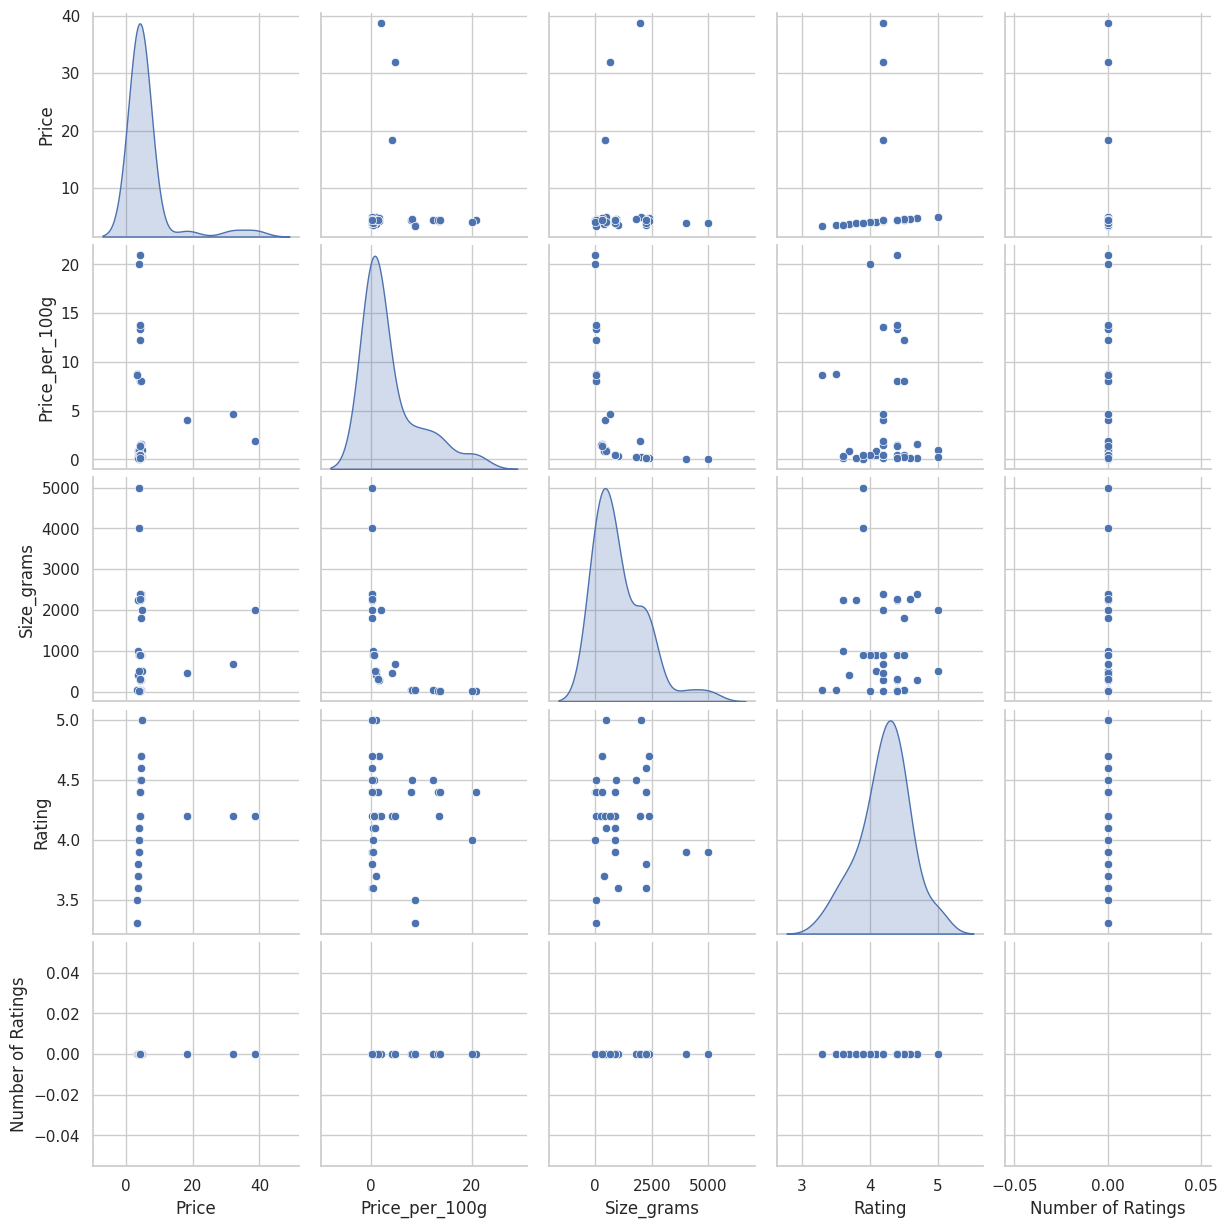

In [ ]:
sns.pairplot(df_clean[['Price','Price_per_100g','Size_grams','Rating','Number of Ratings']], diag_kind='kde')
plt.show()


Categorical + Categorical + Numeric

Example: Boxplot of Price by Flavor grouped by Brand

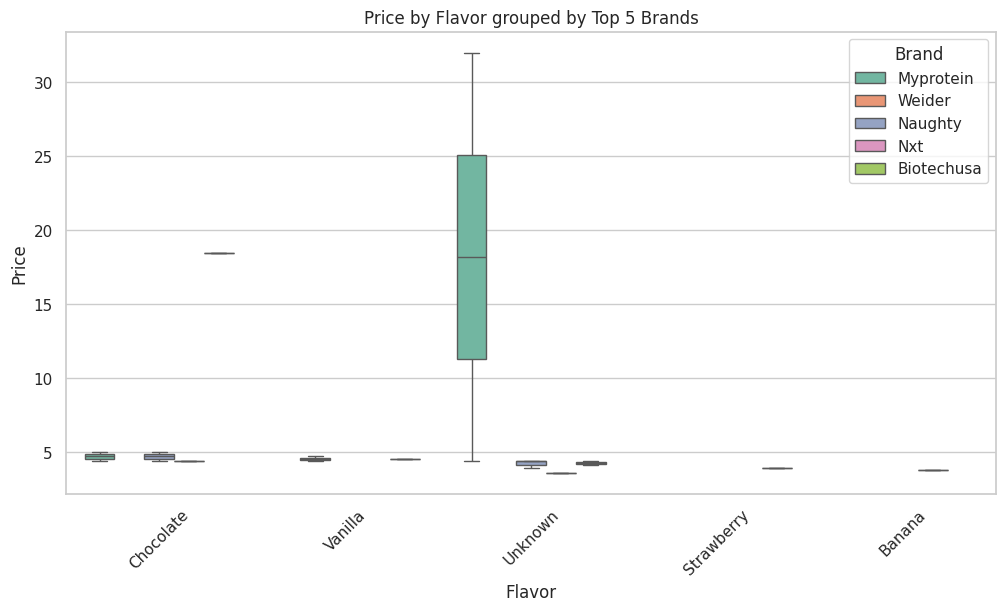

In [ ]:
plt.figure(figsize=(12,6))
top_brands = df_clean['Brand'].value_counts().nlargest(5).index
sns.boxplot(data=df_clean[df_clean['Brand'].isin(top_brands)], x='Flavor', y='Price', hue='Brand', palette='Set2')
plt.title('Price by Flavor grouped by Top 5 Brands')
plt.xticks(rotation=45)
plt.show()


###Conclusion:

###1.Data Quality:

No significant missing values after cleaning.

Outliers in Price, Price per 100g, Size, and Rating were identified and removed for accurate analysis.

### 2.Univariate Analysis:

Brands: Optimum, Scitec, and Biotechusa are the most frequent.

Flavors: Chocolate, Vanilla, and Strawberry dominate the dataset.

Price & Price per 100g: Wide range observed, indicating both budget and premium products.

Ratings: Most products have high ratings (4–5), with a few low-rated exceptions.

### 3.Bivariate Analysis:

Price vs Rating: Higher price does not always mean better rating.

Size vs Price/Price per 100g: Larger sizes tend to have lower price per 100g.

Brand vs Flavor: Certain brands specialize in particular flavors.


### 4.Multivariate Observations:

Boxplots and violin plots highlight variations in price and rating across flavors and brands.

Helps visualize distribution differences across multiple dimensions simultaneously.

Overall: The EDA gives a clear picture of market trends, pricing patterns, and product distribution, providing a solid foundation for any further analysis.